## Phase 1: Clinical Cohort Construction & Data Cleaning
- Import libraries 
- Convert clinical registry to pandas dataframe (from https://portal.gdc.cancer.gov/projects/TCGA-SKCM)
- Inspect dataframe to identify columns of interest and formatting of clinical entries
- Remove text placeholders with null values
- Collapse duplicate rows into a core clinical cohort
- Construct a timeline by establishing a 'survival_months' column
- Assign binary values for Vital_Status ('DEAD' = 1, 'ALIVE' = 0)
- Removing patient data with missing survival outcomes


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lifelines

In [2]:
# Load clinical data as dataframes
dc = pd.read_csv('clinical.tsv', sep='\t')

# Inspect clinical data columns
for col in dc.columns:
    print(col)

# Identify columns of interest:
    # cases.submitter_id
    # demographic.vital_status
    # diagnoses.days_to_last_follow_up
    # demographic.days_to_death

# Inspect formatting of clinical data entries
print(dc[['cases.submitter_id',
          'demographic.vital_status',
          'diagnoses.days_to_last_follow_up',
          'demographic.days_to_death']].head())

project.project_id
cases.case_id
cases.consent_type
cases.days_to_consent
cases.days_to_lost_to_followup
cases.disease_type
cases.index_date
cases.lost_to_followup
cases.primary_site
cases.submitter_id
demographic.age_at_index
demographic.age_is_obfuscated
demographic.cause_of_death
demographic.cause_of_death_source
demographic.country_of_birth
demographic.country_of_residence_at_enrollment
demographic.days_to_birth
demographic.days_to_death
demographic.demographic_id
demographic.education_level
demographic.ethnicity
demographic.marital_status
demographic.occupation_duration_years
demographic.population_group
demographic.race
demographic.sex_at_birth
demographic.submitter_id
demographic.vital_status
demographic.year_of_birth
demographic.year_of_birth_range
demographic.year_of_death
diagnoses.adrenal_hormone
diagnoses.age_at_diagnosis
diagnoses.ajcc_clinical_m
diagnoses.ajcc_clinical_n
diagnoses.ajcc_clinical_stage
diagnoses.ajcc_clinical_t
diagnoses.ajcc_pathologic_m
diagnoses.ajcc_pat

In [3]:
# Remove text placeholders with null values and ensure only numerical data is stored in numeric columns
dc['diagnoses.days_to_last_follow_up'] = pd.to_numeric(dc['diagnoses.days_to_last_follow_up'], errors='coerce')
dc['demographic.days_to_death'] = pd.to_numeric(dc['demographic.days_to_death'], errors='coerce')

# Collapse duplicate rows
dc = dc.groupby('cases.submitter_id').agg({
    'demographic.vital_status':'first', # 'first' is appropriate as patient vital status remains constant between duplicates
    'diagnoses.days_to_last_follow_up':'max', # 'max' is appropriate to measure the latest known duration of survival given available data
    'demographic.days_to_death':'max' # 'max' is appropriate to measure the total recorded duration of survival
}).reset_index()

# Compile columns of interest into a single dataframe
df = dc[['cases.submitter_id','demographic.vital_status','diagnoses.days_to_last_follow_up','demographic.days_to_death']].copy()

In [4]:
# Construct a timeline by establishing a 'survival_months' column, combining data from 'diagnoses.days_to_last_follow_up' and'demographic.days_to_death'
# Measure survival duration by days_to_death if deceased, or by days_to_last_follow_up if alive, as per standard analysis practices
df['survival_months'] = np.where(df['demographic.days_to_death'].notna() == True, df['demographic.days_to_death']/30.44, df['diagnoses.days_to_last_follow_up']/30.44)
df['event'] = np.where(df['demographic.vital_status'] == 'Dead', 1, 0)

# Verify there are no non-standard entries in 'demographic.vital_status'
df['demographic.vital_status'].unique()

array(['Dead', 'Alive'], dtype=object)

In [5]:
# To prevent future pipeline errors, identify patients with a missing survival outcomes
print(df.info())

# Remove said patients from dataframe
df = df.dropna(subset=['survival_months'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470 entries, 0 to 469
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   cases.submitter_id                470 non-null    object 
 1   demographic.vital_status          470 non-null    object 
 2   diagnoses.days_to_last_follow_up  462 non-null    float64
 3   demographic.days_to_death         221 non-null    float64
 4   survival_months                   462 non-null    float64
 5   event                             470 non-null    int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 22.2+ KB
None


## Phase 2: Univariate Stratified Survival Modeling
- Load and isolate BRAF genetic data onto dataframe (from https://portal.gdc.cancer.gov/analysis_page?app=CohortLevelMAF)
- Extract patient ID from tumour barcode 
- Identify unique patient IDs to deduplicate data
- Match mutation status to each patient
- Visually plot the Kaplan-Meier survival curve, comparing the WT and MUT group within BRAF_Mutation
- Perform a Log-Rank test to calculate a formal p-value comparing the survival distribution of the Wildtype and Mutant groups.

In [6]:
# Load mutation list from https://portal.gdc.cancer.gov/analysis_page?app=CohortLevelMAF onto pandas dataframe
dfm = pd.read_csv('mutations.maf', sep='\t', comment='#')

# Isolate BRAF gene data
dfbraf = dfm[dfm['Hugo_Symbol'] == 'BRAF'].copy()

# Extract patient ID from tumour barcode
dfbraf['cases.submitter_id'] = dfbraf['Tumor_Sample_Barcode'].str.slice(0,12)

# Construct list of patients with a BRAF mutation
mutant_tumours = dfbraf['cases.submitter_id'].unique()

# Construct a 'mutation status' column by initially assuming wildtype status and subsequently assigning mutation status to relevant patients using list.
df['BRAF_status'] = 'WT'
df.loc[df['cases.submitter_id'].isin(mutant_tumours),'BRAF_status'] = 'MUT'

print(df.head())

  cases.submitter_id demographic.vital_status  \
0       TCGA-3N-A9WB                     Dead   
1       TCGA-3N-A9WC                    Alive   
2       TCGA-3N-A9WD                     Dead   
3       TCGA-BF-A1PU                    Alive   
4       TCGA-BF-A1PV                    Alive   

   diagnoses.days_to_last_follow_up  demographic.days_to_death  \
0                             518.0                      518.0   
1                            2022.0                        NaN   
2                             395.0                      395.0   
3                             484.0                        NaN   
4                              14.0                        NaN   

   survival_months  event BRAF_status  
0        17.017083      1         MUT  
1        66.425756      0         MUT  
2        12.976347      1          WT  
3        15.900131      0         MUT  
4         0.459921      0          WT  


<Axes: xlabel='timeline'>

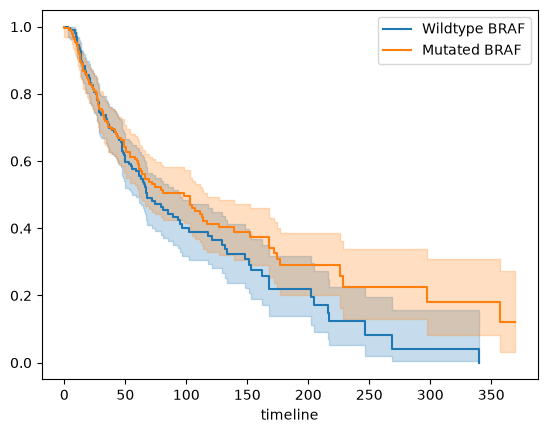

In [7]:
# Separate dataframe for patients carrying wildtype and mutant BRAF genes for stratified Kaplan-Meier curve
dfwt = df[df['BRAF_status'] == 'WT']
dfmut = df[df['BRAF_status'] == 'MUT']

# Plot Kaplan-Meier curve
kmf = lifelines.KaplanMeierFitter()
kmf.fit(durations=dfwt['survival_months'],event_observed=dfwt['event'],label='Wildtype BRAF').plot_survival_function()
kmf.fit(durations=dfmut['survival_months'],event_observed=dfmut['event'],label='Mutated BRAF').plot_survival_function()

In [8]:
# Perform a Log-Rank test to calculate p-value comparing the survival distributions
print(lifelines.statistics.logrank_test(dfwt['survival_months'],dfmut['survival_months'],dfwt['event'],dfmut['event']).p_value)

0.1465909826906241


### Observations
- The Kaplan-Meier curve demonstrates the BRAF mutant group has a noticeable reduction in survival probability relative to the BRAF wildtype group.
- The log-rank test p value (p=0.147) is not statistically significant and provides insufficient evidence to conclude that overall survival differs between BRAF Wildtype and Mutant groups, potentially requiring a larger cohort to confirm a relationship. 

## Phase 3: Multivariate Cox Proportional Hazards Regression Model
- Load and isolate CD8A and CD274 biomarker information (from https://media.githubusercontent.com/media/cBioPortal/datahub/master/public/skcm_tcga/data_mrna_seq_v2_rsem.txt)
- Deduplicate data
- Combine with main clinical dataframe
- Impute missing biomarker expression values
- Construct and plot Cox Proportional Hazards Regression Model

In [ ]:
# Load biomarker information onto pandas dataframe
url = "https://media.githubusercontent.com/media/cBioPortal/datahub/master/public/skcm_tcga/data_mrna_seq_v2_rsem.txt"
dfbm = pd.read_csv(url, sep="\t")

# Isolate target biomarkers (CD8A and CD274)
dfg = dfbm[dfbm['Hugo_Symbol'].isin(['CD8A','CD274'])].copy()

# Identify columns storing patient samples
patient_columns = [c for c in dfg.columns if c.startswith('TCGA')]

# Set gene names as index, slice patient columns, transpose and reset index
df_multi = dfg.set_index('Hugo_Symbol')[patient_columns].T

# Remove 'Hugo_Symbol' from index column name
df_multi.columns.name = None
df_multi= df_multi.reset_index()

# Rename columns
df_multi.columns = ['sample_id', 'CD8A_expr', 'CD274_expr']

# Truncate patient sample IDs (e.g. TCGA-XX-XXXX-01 -> TCGA-XX-XXXX) to match cases.submitter_id
df_multi['cases.submitter_id'] = df_multi['sample_id'].str.slice(0, 12)

# Examine raw RSEM expression data distribution
print(df_multi[['CD8A_expr','CD274_expr']].describe())

# As raw RSEM expression values display a significantly large range, apply log2 transformation: log2(RSEM + 1)
df_multi['CD8A_expr'] = np.log2(df_multi['CD8A_expr'] + 1)
df_multi['CD274_expr'] = np.log2(df_multi['CD274_expr'] + 1)

# Dedeuplicate data by submitter ID by calculating the mean for the expression of each biomarker
df_multi = df_multi.groupby('cases.submitter_id')[['CD8A_expr', 'CD274_expr']].mean().reset_index()

# Create placeholder columns for biomarker expression values
df['CD8A_expr'] = np.nan
df['CD274_expr'] = np.nan

# Create a mapping dictionary for each gene
cd8a_map = df_multi.set_index('cases.submitter_id')['CD8A_expr']
cd274_map = df_multi.set_index('cases.submitter_id')['CD274_expr']

# Map values directly to df based on matching submitter IDs
df['CD8A_expr'] = df['cases.submitter_id'].map(cd8a_map)
df['CD274_expr'] = df['cases.submitter_id'].map(cd274_map)

# Verify that all patient samples have a corresponding CD8A_expr or CD274_expr value
print(df.info())

# CD8A_expr and CD274_expr hold 461 non-null values while cases.submitter_id holds 462 non-null values
# Conclude one patient is missing biomarker expression data

# Identify patient with missing data
# Find the submitter_id missing gene expression data
print(df[df['CD8A_expr'].isna()]['cases.submitter_id'])

# Given n=1 median imputation is appropriate to preserve data
# Impute missing expression with column median
df['CD8A_expr'] = df['CD8A_expr'].fillna(df['CD8A_expr'].median())
df['CD274_expr'] = df['CD274_expr'].fillna(df['CD274_expr'].median())


         CD8A_expr    CD274_expr
count   472.000000    472.000000
mean     60.449492    715.183415
std     150.251765   1331.560480
min       0.000000      0.377100
25%      10.497975     54.690550
50%      24.484250    214.222350
75%      61.518300    780.876200
max    2553.357900  11195.059900
        CD8A_expr  CD274_expr
count  472.000000  472.000000
mean     4.735988    7.629839
std      1.793929    2.588049
min      0.000000    0.461633
25%      3.523308    5.799345
50%      4.671532    7.749666
75%      5.966005    9.610795
max     11.318745   13.450703
<class 'pandas.core.frame.DataFrame'>
Index: 462 entries, 0 to 469
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   cases.submitter_id                462 non-null    object 
 1   demographic.vital_status          462 non-null    object 
 2   diagnoses.days_to_last_follow_up  462 non-null    float64
 3   demographic.da

In [ ]:
# Assign numerical values to BRAF mutation status
dfcox = df[['survival_months', 'event', 'BRAF_status', 'CD8A_expr', 'CD274_expr']].copy()
dfcox['BRAF_status'] = np.where(df['BRAF_status'] == 'MUT',1,0)

# Fit Cox Proportional Hazards Regression Model
cph = lifelines.CoxPHFitter()
cph.fit(dfcox,duration_col='survival_months', event_col='event')

<lifelines.CoxPHFitter: fitted with 462 total observations, 240 right-censored observations>

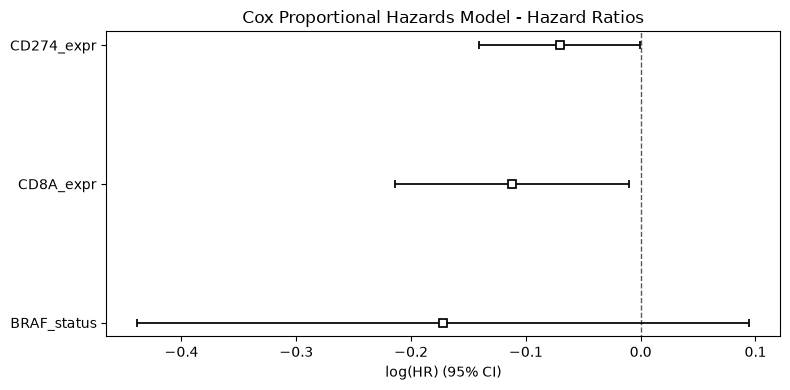

<lifelines.CoxPHFitter: fitted with 462 total observations, 240 right-censored observations>
             duration col = 'survival_months'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 462
number of events observed = 222
   partial log-likelihood = -1132.91
         time fit was run = 2026-07-24 13:26:14 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
BRAF_status -0.17      0.84      0.14           -0.44            0.09                0.64                1.10
CD8A_expr   -0.11      0.89      0.05           -0.21           -0.01                0.81                0.99
CD274_expr  -0.07      0.93      0.04           -0.14           -0.00                0.87                1.00

             cmp to     z    p  -log2(p)
covariate                               
BRAF_status    0.00 -1.26 0.21      2.28
CD8A_expr      0.00 -2.15 0.03      4.98
CD274_expr     0.00 -1.97 0.05      4.36
---
Concordance = 0.62
Partial AIC = 2271.83
log-likelihood ratio test = 30.20 on 3 df
-log2(p) of ll-ratio test = 19.60

In [ ]:
# Plot Cox Proportional Hazards Regression Model
plt.figure(figsize=(8, 4))
cph.plot()
plt.title("Cox Proportional Hazards Model - Hazard Ratios")
plt.tight_layout()
plt.show()
cph.print_summary()

### Hazard Ratio (HR) and Prognostic Significance

The Hazard Ratio (HR) for each covariate are:
- BRAF mutation status: 0.84. This indicates a favourable prognostic factor with decreased risk of death, though the p value (0.21) indicates its effect may be driven by confounding variables.

- CD8A expression level: 0.89 This suggests a favourable prognostic factor with decreased risk of death. The p value (0.03) supports an independent relationship between the variable with overall survival. 

- CD274 expression level: 0.93 This displays a favourable prognostic factor with decreased risk of death. However, the p value (0.05) suggests a marginally significant relationship between the variable with overall survival, requiring further investigation. 


